# 🤖 Real vs. AI-Generated Face Detection

## 📋 **Assignment Overview**

Welcome to this hands-on Deep Learning assignment! You'll build and compare multiple deep learning models to tackle a fascinating modern challenge: **distinguishing real human faces from AI-generated ones**. As AI-generated images become increasingly sophisticated, this task has important implications for digital authenticity, security, and trust online.

## 🎯 **Learning Objectives**

By completing this assignment, you will:
- **Master** fundamental deep learning techniques from simple MLPs to advanced CNNs
- **Implement** data augmentation strategies to improve model generalization
- **Apply** transfer learning using state-of-the-art pre-trained models
- **Optimize** models through fine-tuning, batch normalization and other techniques
- **Deploy** an interactive web application for real-world testing
- **Analyze** and compare different architectural approaches

## 🗂️ **Assignment Structure**

| Part | Topic | Description | Key Skills | Status |
|------|-------|-------------|------------|--------|
| **0** | 🗂️ Dataset Setup | Load and preprocess face images | Data handling, normalization | ✅ Provided |
| **1** | 🔍 Data Exploration | Visualize and understand the dataset | EDA, visualization | ✅ Provided |
| **2** | 🧠 MLP Baseline | Build a simple neural network classifier | Dense layers, fundamentals | ✅ Provided |
| **3** | 🖼️ CNN Implementation | Design a convolutional neural network | Conv2D, pooling, spatial features | ✅ Provided |
| **4** | 🎨 Data Augmentation | Enhance training with image transformations | ImageDataGenerator, regularization | 📝 **TODO** |
| **5** | 🚀 Transfer Learning | Leverage MobileNetV3 pre-trained model | Feature extraction, fine-tuning | 📝 **TODO** |
| **6** | 🔧 Fine-Tuning | Unfreeze and optimize top layers | Advanced optimization | 📝 **TODO** |
| **7** | 📊 Model Comparison | Analyze all models comprehensively | Performance analysis, visualization | 📝 **TODO** |
| **8** | 🎮 Interactive Demo | Build and deploy a Gradio game | Deployment, UI/UX design | 📝 **TODO** |


## 📊 **Dataset Information**
- **Source**: Curated collection of real and AI-generated faces
- **Size**: ~1200 RGB images (128×128×3 pixels)
- **Classes**: Binary classification (Real vs. AI-generated)
- **Automatic Download**: The dataset will be automatically downloaded from the instructor's Google Drive when you run Part 0
- **Directory Structure**:
  - `training_real/` - Real face images for training
  - `training_AI/` - AI-generated face images for training
  - `test_real/` - Real face images for testing
  - `test_AI/` - AI-generated face images for testing
- **Important**: The test set is fixed and identical for all students to ensure fair comparison across the class

---

🚀 **Let's begin! Run the cells below sequentially to start your journey into distinguishing real from AI-generated faces!**

## Setup: Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")
print(f"Running on: {'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

I0000 00:00:1790962383.028768     394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790962384.391878     394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
Running on: GPU


## 🗂️ Part 1: Dataset Setup & Preprocessing

### 📊 **What's happening in this section?**

In this initial setup phase, we're preparing our dataset for the exciting journey of distinguishing between **real human faces** and **AI-generated faces**!

#### 🎯 **Key Steps:**
- **📥 Dataset Download**: We fetch a curated dataset of face images from the course repository
- **🖼️ Image Processing**: All images are resized to 128×128 pixels
- **📈 Normalization**: Pixel values are scaled to [0,1] range for optimal neural network training
- **🔀 Data Splitting**: We organize our data into three sets:
  - **Test set**: Dedicated, separate set of 300 images (150 per class) for final evaluation
  - **Training set** (85%): For model learning
  - **Validation set** (15%): For hyperparameter tuning


#### ⚠️ **Important Notes:**
- This cell contains pre-configured code that should **NOT be modified**
- The dataset is balanced with equal numbers of real and AI-generated faces
- All images are processed identically to ensure fair comparison

🚀 **Run the cell below to automatically download and prepare your dataset!**

In [2]:
# ============================================================
# Part 0 - Dataset Setup (Do NOT Modify)
# ============================================================

!pip install -q gdown

import gdown
import os
import zipfile
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Course dataset (hosted on instructor's Google Drive)
#FILE_ID = "1h0kxOEQ5tYvW3eb_xM2mdwhozgG6zPYo"  # Provided by instructor

FILE_ID = "154rbZmY2HI0qVbBVEJ1nbvoHDJmY7fQX"  # Provided by instructor
url = f"https://drive.google.com/uc?id={FILE_ID}"

print("📥 Downloading dataset from course repository...")
output_path = '/content/real_and_AI.zip'

try:
    gdown.download(url, output_path, quiet=False)

    print("\n📦 Extracting files...")
    with zipfile.ZipFile(output_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

    # Clean up zip file
    os.remove(output_path)

    # Verify the download
    real_count = len(os.listdir('/content/real_and_AI/training_real'))
    fake_count = len(os.listdir('/content/real_and_AI/training_AI'))

    print("\n✅ Dataset successfully loaded!")
    print(f"   • Real faces: {real_count} images")
    print(f"   • AI faces: {fake_count} images")

except Exception as e:
    print(f"❌ Error downloading dataset: {e}")
    print("Please contact the instructor if this persists.")




📥 Downloading dataset from course repository...


Downloading...
From (original): https://drive.google.com/uc?id=154rbZmY2HI0qVbBVEJ1nbvoHDJmY7fQX
From (redirected): https://drive.google.com/uc?id=154rbZmY2HI0qVbBVEJ1nbvoHDJmY7fQX&confirm=t&uuid=a207963c-b4de-4ead-8f8b-9f0da1818105
To: /content/real_and_AI.zip


  0%|          | 0.00/66.9M [00:00<?, ?B/s]

  2%|▏         | 1.05M/66.9M [00:00<00:07, 9.08MB/s]

 13%|█▎        | 8.91M/66.9M [00:00<00:01, 46.9MB/s]

...

 81%|████████▏ | 54.5M/66.9M [00:00<00:00, 79.8MB/s]

 98%|█████████▊| 65.5M/66.9M [00:00<00:00, 87.9MB/s]

100%|██████████| 66.9M/66.9M [00:00<00:00, 72.1MB/s]


📦 Extracting files...



✅ Dataset successfully loaded!
   • Real faces: 1001 images
   • AI faces: 1001 images


In [3]:
# ============================================================
# Load images into arrays (Do NOT Modify)
# ============================================================
print("\n" + "="*50)
print("Loading images into arrays...")

def load_images_from_folder(folder_path, label, max_images=600, target_size=(128, 128)):
    """
    Load images from a folder and assign a label.
    Images are loaded as RGB (3 channels) and normalized to [0, 1].
    """
    images, labels = [], []

    # Filter out hidden files (e.g. .DS_Store) and non-image files
    valid_extensions = ('.jpg', '.jpeg')
    image_files = [
        f for f in sorted(os.listdir(folder_path))
        if not f.startswith('.') and f.lower().endswith(valid_extensions)
    ][:max_images]

    for img_file in image_files:
        img_path = os.path.join(folder_path, img_file)
        try:
            img = Image.open(img_path)
            img = img.resize(target_size)
            img_array = np.array(img) / 255.0  # Normalize [0, 1]
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"⚠️ Error loading {img_file}: {e}")

    return np.array(images), np.array(labels)

# Paths
data_path = '/content/real_and_AI/'

# Training images
print("Loading real training images...")
real_images, real_labels = load_images_from_folder(
    os.path.join(data_path, 'training_real'),
    label=1
)
print("Loading AI-generated training images...")
fake_images, fake_labels = load_images_from_folder(
    os.path.join(data_path, 'training_AI'),
    label=0
)

# Combine training
X = np.concatenate([real_images, fake_images])
y = np.concatenate([real_labels, fake_labels])

# Test images (new fixed folders)
print("Loading real test images...")
test_real_images, test_real_labels = load_images_from_folder(
    os.path.join(data_path, 'test_real'),
    label=1
)
print("Loading fake test images...")
test_fake_images, test_fake_labels = load_images_from_folder(
    os.path.join(data_path, 'test_AI'),
    label=0
)

X_test = np.concatenate([test_real_images, test_fake_images])
y_test = np.concatenate([test_real_labels, test_fake_labels])

# Reshape
X = X.reshape(X.shape[0], 128, 128, 3)
X_test = X_test.reshape(X_test.shape[0], 128, 128, 3)

# Split training further into train/val (70/15/15 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"\n✅ Dataset ready for training!")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")
print(f"Real images: {np.sum(y == 1)} | Fake images: {np.sum(y == 0)}")


Loading images into arrays...
Loading real training images...


Loading AI-generated training images...


Loading real test images...


Loading fake test images...



✅ Dataset ready for training!
Train: 1020 | Val: 180 | Test: 300
Image shape: (128, 128, 3)
Real images: 600 | Fake images: 600


### 🔍 Data Exploration & Visualization

### 📊 **Understanding Our Dataset**

Before diving into model building, let's explore and visualize our face dataset to understand what we're working with! This exploration phase is crucial for gaining insights into the characteristics of real vs. AI-generated faces.

#### 🎯 **What we'll discover:**
- **📐 Data Dimensions**: Verify the shapes of our train, validation, and test sets
- **🖼️ Visual Comparison**: Side-by-side comparison of real and AI-generated face samples
- **👤 Average Faces**: Compute the "average" real face vs. the "average" AI face to spot patterns
- **📈 Class Distribution**: Check the balance between real and fake images across all sets

#### 🔬 **Key Observations to Look For:**
- **Texture differences**: AI faces might have smoother or more uniform textures
- **Feature consistency**: Real faces typically show more natural variations
- **Averaged patterns**: The average faces reveal common characteristics of each class

#### 💡 **Pro Tip:**
Pay attention to subtle differences in the averaged faces - these patterns are what our neural network will learn to distinguish!

🚀 **Run the cell below to explore your dataset visually!**

Shapes:
 X_train: (1020, 128, 128, 3)  y_train: (1020,)
 X_val:   (180, 128, 128, 3)  y_val:   (180,)
 X_test:  (300, 128, 128, 3)  y_test:  (300,)



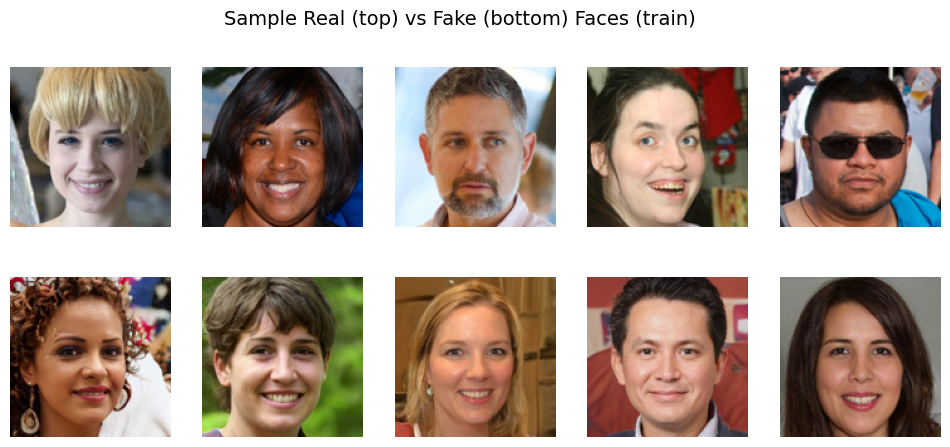

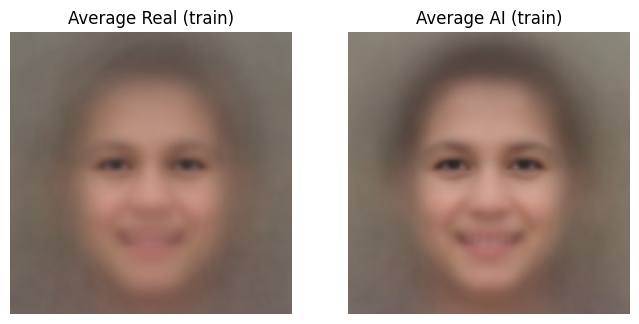

📊 Dataset statistics:
 Train  - Real: 510  AI: 510
 Val    - Real: 90  AI: 90
 Test   - Real: 150  AI: 150


In [4]:
# ============================================================
# Part 1 - Data Exploration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Quick sanity checks
print("Shapes:")
print(" X_train:", X_train.shape, " y_train:", y_train.shape)
print(" X_val:  ", X_val.shape, " y_val:  ", y_val.shape)
print(" X_test: ", X_test.shape, " y_test: ", y_test.shape)
print()

# Show sample real vs fake images from training set
def pick_n_per_class(X, y, n=5, cls=1):
    idxs = np.where(y == cls)[0]
    sel = np.random.choice(idxs, size=min(n, len(idxs)), replace=False)
    return X[sel]

np.random.seed(42)
real_samples = pick_n_per_class(X_test, y_test, n=5, cls=1)
fake_samples = pick_n_per_class(X_test, y_test, n=5, cls=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Real (top) vs Fake (bottom) Faces (train)", fontsize=14)

for i in range(5):
    axes[0, i].imshow(real_samples[i].reshape(128, 128, 3))
    axes[0, i].axis("off")
    axes[1, i].imshow(fake_samples[i].reshape(128, 128, 3))
    axes[1, i].axis("off")
plt.show()

# Compute average faces (train)
avg_real = X_train[y_train == 1].mean(axis=0)
avg_fake = X_train[y_train == 0].mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(avg_real.reshape(128, 128, 3)); ax1.set_title("Average Real (train)"); ax1.axis("off")
ax2.imshow(avg_fake.reshape(128, 128, 3)); ax2.set_title("Average AI (train)"); ax2.axis("off")
plt.show()

# Basic stats
print("📊 Dataset statistics:")
print(" Train  - Real:", np.sum(y_train==1), " AI:", np.sum(y_train==0))
print(" Val    - Real:", np.sum(y_val==1),   " AI:", np.sum(y_val==0))
print(" Test   - Real:", np.sum(y_test==1),  " AI:", np.sum(y_test==0))


## 🧠 Part 2: Multi-Layer Perceptron (MLP) Classifier

### 🏗️ **Building Our First Neural Network**

Time to build our baseline model! We'll start with a classic **Multi-Layer Perceptron (MLP)** - a fully connected neural network that will learn to distinguish real faces from AI-generated ones.

#### 🎯 **Architecture Overview:**
- **Input Layer**: Flattens our 128×128 grayscale images into a 49,152-dimensional vector
- **Hidden Layers**: Three dense layers with decreasing neurons (64 → 32 → 16 → 1)
- **Activation**: ReLU functions for non-linearity in hidden layers
- **Output Layer**: Single neuron with sigmoid activation for binary classification

#### ⚙️ **Training Configuration:**
- **📉 Optimizer**: Adam with learning rate = 0.001
- **🎲 Loss Function**: Binary cross-entropy (perfect for binary classification)
- **📊 Metrics**: Accuracy for intuitive performance tracking
- **🔄 Epochs**: 20 iterations through the entire dataset
- **📦 Batch Size**: 32 samples processed together

#### 📈 **What to Monitor:**
- **Training vs. Validation Curves**: Watch for overfitting if curves diverge
- **Best Validation Accuracy**: The peak performance on unseen data
- **Test Accuracy**: Final unbiased evaluation on held-out test set

#### 💡 **Key Insight:**
MLPs treat images as flat vectors, ignoring spatial relationships between pixels. This baseline will help us appreciate the power of CNNs in the next section!

🚀 **Run the cell below to train your first face detector!**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

...

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8750 - loss: 0.3293

13/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8431 - loss: 0.3486 

26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8389 - loss: 0.3656

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8422 - loss: 0.3757 - val_accuracy: 0.6722 - val_loss: 0.6230


MLP best val acc: 0.7056 at epoch 16


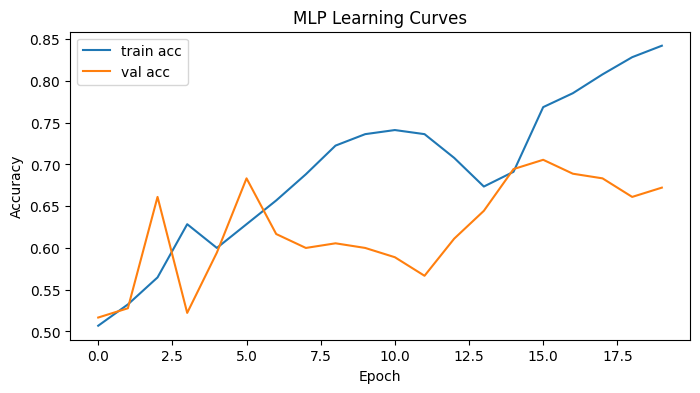

MLP test accuracy: 0.6500


In [5]:
# ============================================================
# Part 2 - Multi-Layer Perceptron
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input # Import Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

tf.random.set_seed(42)

mlp_model = Sequential([
    Input(shape=(128, 128, 3)),  # Use Input layer for input shape
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(mlp_model.summary())

history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Best validation accuracy and epoch
best_val_acc_mlp = np.max(history_mlp.history['val_accuracy'])
best_epoch_mlp = np.argmax(history_mlp.history['val_accuracy']) + 1
print(f"MLP best val acc: {best_val_acc_mlp:.4f} at epoch {best_epoch_mlp}")

# Plot learning curves
plt.figure(figsize=(8,4))
plt.plot(history_mlp.history['accuracy'], label='train acc')
plt.plot(history_mlp.history['val_accuracy'], label='val acc')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("MLP Learning Curves")
plt.show()

# Evaluate on test set
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"MLP test accuracy: {mlp_test_acc:.4f}")

## 🖼️ Part 3: Convolutional Neural Network (CNN) - Baseline

### 🚀 **Leveraging Spatial Features with CNNs**

Now we're stepping up our game! Unlike MLPs that treat images as flat vectors, **Convolutional Neural Networks** understand the spatial structure of images, making them perfect for computer vision tasks.

#### 🏗️ **Architecture Breakdown:**
- **🔍 Conv Layers**: Multiple convolutional blocks with increasing filters (16→32→64)
- **📉 MaxPooling**: (2×2) after each block - Reduces spatial dimensions
- **🎯 BatchNormalization**: Normalizes activations for faster, more stable training
- **💧 Dropout**: Randomly drops connections to prevent overfitting
- **🌐 GlobalAveragePooling2D**: Elegantly reduces feature maps to single values
- **🧠 Dense Layers**: Final classification head with dropout

#### ⚙️ **Key Techniques:**
- **BatchNormalization**: Stabilizes training by normalizing layer inputs
- **Dropout**: Regularization technique (e.g., 0.2 = drop 20% of connections)
- **GlobalAveragePooling2D**: Better than Flatten() - reduces parameters and overfitting
- **Model Checkpointing**: Saves best model based on validation loss

#### 🔬 **What Makes CNNs Special:**
- **Local Connectivity**: Filters scan local regions, detecting patterns anywhere in the image
- **Parameter Sharing**: Same filter applied across the entire image
- **Hierarchical Learning**: Early layers detect edges → Middle layers detect shapes → Deep layers detect faces
- **Translation Invariance**: Can recognize features regardless of position

#### 📊 **Modern Best Practices Applied:**
- Conv → BatchNorm → Activation → Pool → Dropout (repeated blocks)
- GlobalAveragePooling instead of Flatten (fewer parameters, better generalization)
- Gradual increase in filters (16→32→64) as spatial dimensions decrease

🚀 **Run the cell below to train your CNN baseline model with these modern techniques!**

/home/kavinn/hw1-gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,641 (119.69 KB)

 Trainable params: 30,225 (118.07 KB)

...

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7151 - loss: 0.5518


Epoch 25: val_loss did not improve from 0.69295


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7010 - loss: 0.5656 - val_accuracy: 0.5056 - val_loss: 0.8515


>> CNN baseline best val acc: 0.5444 at epoch 1


>> CNN baseline test acc (best model): 0.4933


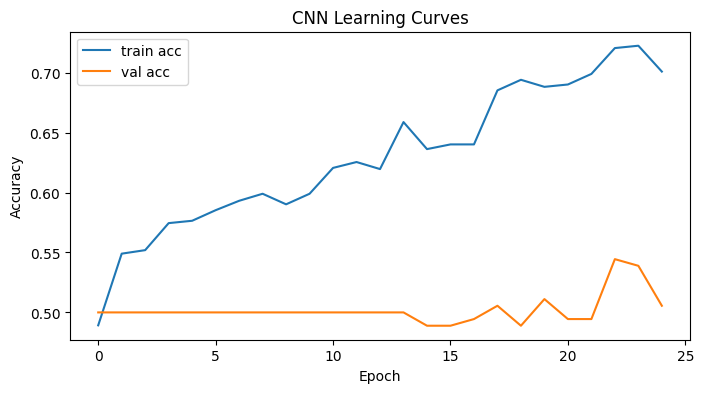

In [6]:
# ============================================================
# Part 3 - CNN (Baseline)
# ============================================================

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# ---- CNN baseline ----

cnn_model = Sequential([
    # First conv block
    Conv2D(16, (3,3), padding='same', use_bias=False, input_shape=(128,128,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    # Second conv block
    Conv2D(32, (3,3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    # Third conv block
    Conv2D(64, (3,3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    GlobalAveragePooling2D(),

    Dense(96),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),  # ← Increased final dropout

    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

checkpoint_cnn_path = "best_cnn_baseline.keras"
checkpoint_cnn = ModelCheckpoint(checkpoint_cnn_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[checkpoint_cnn],
    verbose=1
)

best_val_acc_cnn = np.max(history_cnn.history['val_accuracy'])
best_val_loss_cnn = np.min(history_cnn.history['val_loss'])
best_epoch_cnn = np.argmin(history_cnn.history['val_loss']) + 1
print(f">> CNN baseline best val acc: {best_val_acc_cnn:.4f} at epoch {best_epoch_cnn}")

# Load best baseline cnn and evaluate on test set
best_cnn = load_model(checkpoint_cnn_path)
cnn_test_loss, cnn_test_acc = best_cnn.evaluate(X_test, y_test, verbose=0)
print(f">> CNN baseline test acc (best model): {cnn_test_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(8,4))
plt.plot(history_cnn.history['accuracy'], label='train acc')
plt.plot(history_cnn.history['val_accuracy'], label='val acc')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("CNN Learning Curves")
plt.show()



## 🚀 [TO DO] Part 4: CNN with Data Augmentation

### 🔄 **Why Data Augmentation Matters**

Data augmentation helps getting the most out of the data and also prevent overfitting by creating realistic variations of training images, effectively expanding your dataset without collecting new data. This makes models more robust and better at generalizing to unseen data.

#### 🎯 **Your Task:**
Enhance your CNN's performance using data augmentation for the real vs. AI face classification task.

#### 📝 **Implementation Guide:**

1. **Start with your Part 3 CNN architecture**

2. **Add data augmentation** (choose one approach):
   - **Option A**: Use `ImageDataGenerator` (simpler, but deprecated)
   - **Option B**: Use `tf.keras.layers` augmentation layers (modern approach)
   - Select a single, thoughtful combination of subtle transformations suited for faces (e.g., slight rotation, shifts, horizontal flips, etc; these are examples, not an exhaustive checklist).
   - **Note**: You do not need to test every permutation or run an ablation study—focus on one well-justified pipeline.

3. **Train with augmented data**:
   - Apply augmentation ONLY to training data
   - Keep validation data unchanged

4. **Evaluate and compare**:
   - Plot learning curves
   - Compare with baseline performance

#### 🏷️ **Variable Naming**:
- Model: `cnn_aug_model`
- History: `history_cnn_aug`
- Checkpoint: `"best_cnn_aug.keras"`
- Test accuracy: `cnn_aug_test_acc`

#### 💡 **Tips:**
- Start with conservative augmentation parameters
- Monitor validation curves to ensure augmentation is helping
- Good augmentation should reduce the train-validation gap

🚀 **Implement your augmented CNN below:**

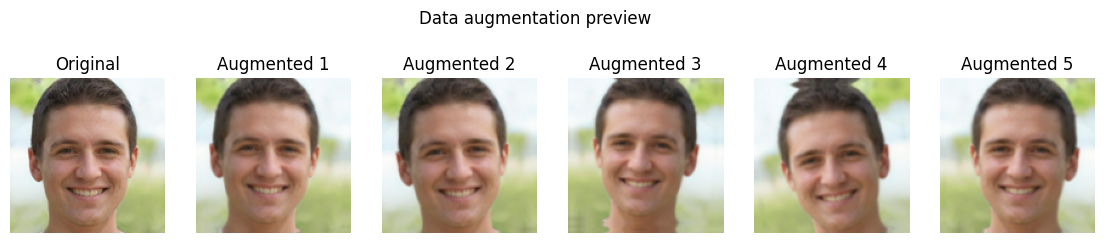

Model: "cnn_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 30,641 (119.69 KB)

 Trainable params: 30,225 (118.07 KB)

 Non-trainable params: 416 (1.62 KB)

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7667 - loss: 0.5007 - val_accuracy: 0.5333 - val_loss: 1.0131 - learning_rate: 1.5625e-05


Epoch 78: early stopping


Restoring model weights from the end of the best epoch: 48.


>> CNN+Aug best val acc: 0.6389 at epoch 48


>> CNN+Aug test acc (best model): 0.6500


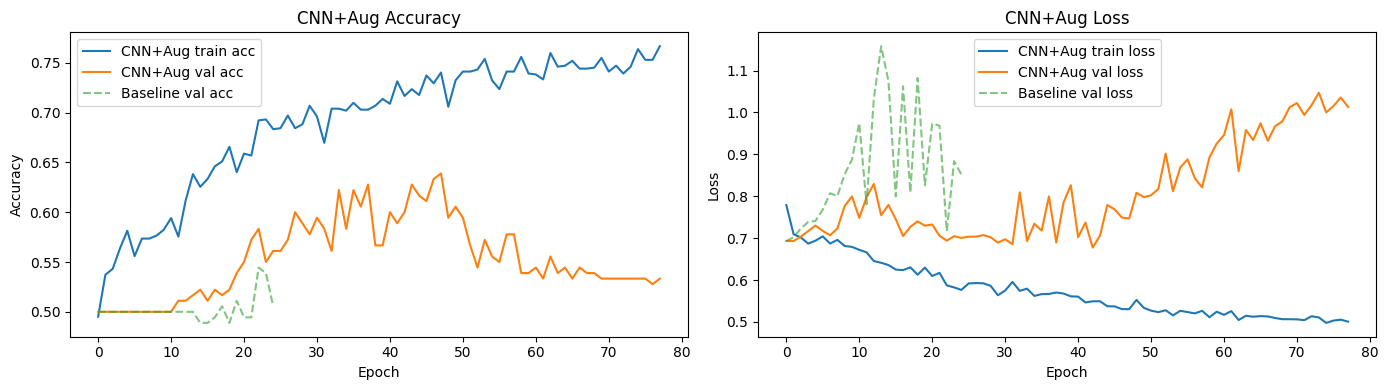


Model           Best val acc  Test acc   Train-val gap
CNN baseline          0.5444    0.4933          0.1911
CNN+Aug               0.6389    0.6500          0.2242
Test accuracy change vs. baseline: +0.1567


In [7]:
# ============================================================
# CNN with Data Augmentation
# ============================================================

from tensorflow.keras.layers import Input, RandomFlip, RandomRotation, RandomTranslation, RandomZoom
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

# ---- Augmentation pipeline (Option B: Keras preprocessing layers) ----
# Subtle, face-appropriate *geometric* transforms only:
#   - horizontal flip : faces are roughly left/right symmetric, so a mirrored face is still a valid face
#   - rotation ±~11°  : small head tilts
#   - shift ±5%       : imperfect face centring / cropping
#   - zoom ±5%        : small changes in face scale
# Colour / brightness / contrast jitter is deliberately left out: colour statistics and fine
# texture are likely to be the very cues that separate AI faces from real ones.
# These layers are only active in training mode (model.fit), so validation/test data are untouched.
def make_augmentation(name="augmentation"):
    return Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.03),
        RandomTranslation(0.05, 0.05),
        RandomZoom(0.05),
    ], name=name)

# Preview: one training image and 5 random augmentations of it
preview_aug = make_augmentation("preview_aug")
sample_img = X_train[:1].astype("float32")
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample_img[0]); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 6):
    aug_img = preview_aug(sample_img, training=True).numpy()[0]
    axes[i].imshow(np.clip(aug_img, 0, 1)); axes[i].set_title(f"Augmented {i}"); axes[i].axis("off")
plt.suptitle("Data augmentation preview")
plt.show()

# ---- Same architecture as the Part 3 baseline, with augmentation as the first stage ----
cnn_aug_model = Sequential([
    Input(shape=(128, 128, 3)),
    make_augmentation(),

    # First conv block
    Conv2D(16, (3,3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    # Second conv block
    Conv2D(32, (3,3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    # Third conv block
    Conv2D(64, (3,3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.15),

    GlobalAveragePooling2D(),

    Dense(96),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),

    Dense(1, activation='sigmoid')
], name="cnn_aug")

cnn_aug_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
cnn_aug_model.summary()

checkpoint_cnn_aug_path = "best_cnn_aug.keras"
# Monitor val_accuracy (not val_loss): this CNN starts slowly (val acc sits at 0.50 for many epochs, even
# for the baseline), and an untrained epoch-1 model (val_loss ~0.693) can otherwise "win" on val_loss.
checkpoint_cnn_aug = ModelCheckpoint(checkpoint_cnn_aug_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
# Augmentation makes each epoch "harder", so allow more epochs and stop once val_accuracy stalls
# (early stopping only starts counting after epoch 30, so the slow start cannot trigger it)
early_stop_cnn_aug = EarlyStopping(monitor='val_accuracy', mode='max', patience=30, start_from_epoch=30, restore_best_weights=True, verbose=1)
reduce_lr_cnn_aug = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)

history_cnn_aug = cnn_aug_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),   # validation data is NOT augmented
    epochs=150,
    batch_size=32,
    callbacks=[checkpoint_cnn_aug, early_stop_cnn_aug, reduce_lr_cnn_aug],
    verbose=1
)

best_val_acc_cnn_aug = np.max(history_cnn_aug.history['val_accuracy'])
best_epoch_cnn_aug = np.argmax(history_cnn_aug.history['val_accuracy']) + 1
print(f">> CNN+Aug best val acc: {best_val_acc_cnn_aug:.4f} at epoch {best_epoch_cnn_aug}")

# Load best augmented CNN and evaluate on test set
best_cnn_aug = load_model(checkpoint_cnn_aug_path)
cnn_aug_test_loss, cnn_aug_test_acc = best_cnn_aug.evaluate(X_test, y_test, verbose=0)
print(f">> CNN+Aug test acc (best model): {cnn_aug_test_acc:.4f}")

# ---- Learning curves: augmented vs. baseline ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_cnn_aug.history['accuracy'], label='CNN+Aug train acc')
ax1.plot(history_cnn_aug.history['val_accuracy'], label='CNN+Aug val acc')
ax1.plot(history_cnn.history['val_accuracy'], '--', alpha=0.6, label='Baseline val acc')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.set_title("CNN+Aug Accuracy"); ax1.legend()
ax2.plot(history_cnn_aug.history['loss'], label='CNN+Aug train loss')
ax2.plot(history_cnn_aug.history['val_loss'], label='CNN+Aug val loss')
ax2.plot(history_cnn.history['val_loss'], '--', alpha=0.6, label='Baseline val loss')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.set_title("CNN+Aug Loss"); ax2.legend()
plt.tight_layout(); plt.show()

# ---- Comparison with baseline ----
def train_val_gap(history, last_n=5):
    """Mean (train acc - val acc) over the last `last_n` epochs."""
    tr = np.array(history.history['accuracy'][-last_n:])
    va = np.array(history.history['val_accuracy'][-last_n:])
    return float(np.mean(tr - va))

print(f"\n{'Model':<14}{'Best val acc':>14}{'Test acc':>10}{'Train-val gap':>16}")
print(f"{'CNN baseline':<14}{best_val_acc_cnn:>14.4f}{cnn_test_acc:>10.4f}{train_val_gap(history_cnn):>16.4f}")
print(f"{'CNN+Aug':<14}{best_val_acc_cnn_aug:>14.4f}{cnn_aug_test_acc:>10.4f}{train_val_gap(history_cnn_aug):>16.4f}")
print(f"Test accuracy change vs. baseline: {cnn_aug_test_acc - cnn_test_acc:+.4f}")

## 🚀 [TO DO] Part 5: Transfer Learning with MobileNetV3

---



### 🎓 **Standing on the Shoulders of Giants**

Why train from scratch when we can leverage models that have already learned from millions of images? **Transfer learning** allows us to use pre-trained models as powerful feature extractors. **MobileNetV3** (from ICCV 2019), trained on ImageNet's 1.4 million images, has already learned to recognize complex visual patterns that we can adapt for our face detection task!

#### 🎯 **Your Task:**
Implement transfer learning using MobileNetV3Small as a feature extractor for distinguishing real vs. AI-generated faces.

#### 🔎 **Check out their Paper/Presentation [OPTIONAL]:**
https://openaccess.thecvf.com/content_ICCV_2019/html/Howard_Searching_for_MobileNetV3_ICCV_2019_paper.html

#### 📝 **Implementation Steps:**

1. **🔄 Data Preprocessing**:
   - Ensure input pixel values match the expected format for MobileNetV3 before passing them into the model. https://keras.io/api/applications/mobilenet/
   - Prepare your processed train, validation, and test splits.

2. **📦 Load Pre-trained MobileNetV3Small**:
   - Instantiate `MobileNetV3Small` with pre-trained ImageNet weights
   - Exclude the top classification layer (`include_top=False`) and configure global average pooling to extract dense feature representations.

3. **🔒 Freeze Base Model**:
   - Set `base.trainable = False` to preserve ImageNet features

4. **🏗️ Build Complete Model**:
   - Add a custom classification head on top of the pooled backbone output.
    - Experiment with your head's structure to achieve the best generalization on validation data.

5. **⚙️ Compile & Train**:
   - Select an optimizer and an appropriate learning rate for training a newly initialized head on frozen features.
   - Consider data augmentation for better generalization
   - Save best model with ModelCheckpoint

6. **📊 Evaluate**:
   - Plot your learning curves (training loss vs. validation loss, training accuracy vs. validation accuracy).
   - Evaluate and report performance on the held-out test set.

#### 🏷️ **Variable Naming Convention**:
- Preprocessed data: `X_train_pp`, `X_val_pp`, `X_test_pp`
- Model: `mobilenet_frozen`
- History: `history_mob_frozen`

#### 💡 **Pro Tips:**
- MobileNetV3Small has ~1.5M parameters - keep them fully frozen for this task
- The warning regarding input shape adaptation (224x224 to 128x128) is normal for fully convolutional backbones with global pooling.
- Transfer learning should converge quickly (often best results within 10-20 epochs)


🚀 **Time to harness the power of transfer learning! Code below:**

Preprocessed pixel range: [0.0, 255.0]
Train: (1020, 128, 128, 3) | Val: (180, 128, 128, 3) | Test: (300, 128, 128, 3)


/home/kavinn/hw1-gpu/lib/python3.10/site-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Backbone: 158 layers, 939,120 params (all frozen)


Model: "mobilenet_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mob_augmentation (Sequential)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 576)            │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7824 - loss: 0.4568 - val_accuracy: 0.7111 - val_loss: 0.5798


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 5.


>> MobileNet (frozen) best val acc: 0.7389 (best val_loss at epoch 5)


>> MobileNet (frozen) test acc (best model): 0.7233


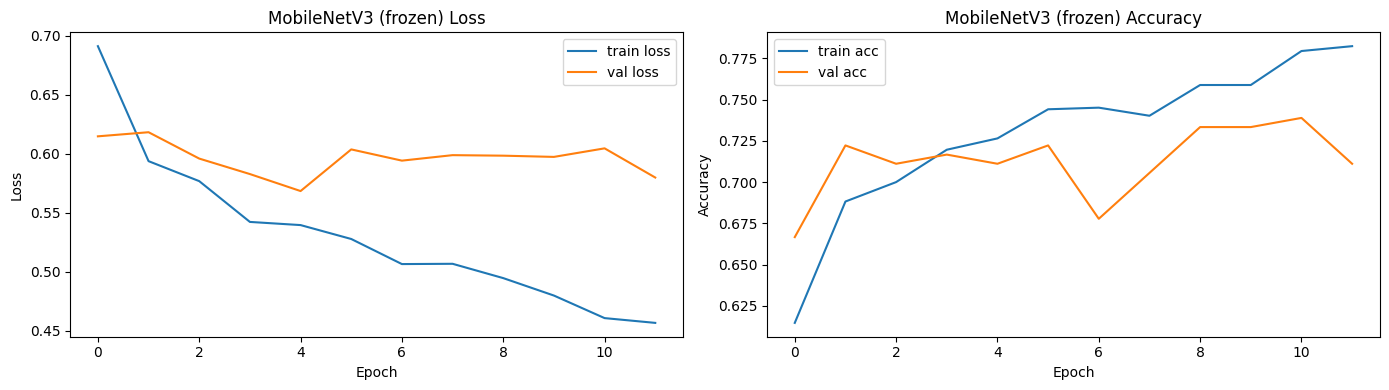

In [8]:
# ============================================================
# Part 5 - Transfer Learning (MobileNetV3Small)
# ============================================================

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model

tf.random.set_seed(42)

# ---- 1) Preprocessing ----
# Keras' MobileNetV3 has a built-in Rescaling layer (include_preprocessing=True) and expects
# raw pixel values in [0, 255]. Our arrays were normalised to [0, 1], so scale them back up.
X_train_pp = (X_train * 255.0).astype("float32")
X_val_pp   = (X_val   * 255.0).astype("float32")
X_test_pp  = (X_test  * 255.0).astype("float32")
print(f"Preprocessed pixel range: [{X_train_pp.min():.1f}, {X_train_pp.max():.1f}]")
print(f"Train: {X_train_pp.shape} | Val: {X_val_pp.shape} | Test: {X_test_pp.shape}")

# ---- 2) Pre-trained backbone (no top; global average pooling -> 576-d feature vector) ----
base_model = MobileNetV3Small(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg",
    include_preprocessing=True,
)

# ---- 3) Freeze the backbone ----
base_model.trainable = False
print(f"Backbone: {len(base_model.layers)} layers, {base_model.count_params():,} params (all frozen)")

# ---- 4) Full model: light augmentation -> frozen backbone -> custom head ----
inputs = Input(shape=(128, 128, 3))
x = make_augmentation("mob_augmentation")(inputs)   # same subtle pipeline as Part 4 (train-time only)
x = base_model(x, training=False)                   # keep BatchNorm layers in inference mode
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)
mobilenet_frozen = Model(inputs, outputs, name="mobilenet_frozen")

# ---- 5) Compile & train (only the head is trainable, so a standard LR is fine) ----
mobilenet_frozen.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
mobilenet_frozen.summary()

checkpoint_mob_frozen_path = "best_mobilenet_frozen.keras"
checkpoint_mob_frozen = ModelCheckpoint(checkpoint_mob_frozen_path, monitor="val_loss", save_best_only=True, mode="min", verbose=1)
early_stop_mob_frozen = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1)

history_mob_frozen = mobilenet_frozen.fit(
    X_train_pp, y_train,
    validation_data=(X_val_pp, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint_mob_frozen, early_stop_mob_frozen],
    verbose=1
)

best_val_acc_mob_frozen = np.max(history_mob_frozen.history["val_accuracy"])
best_epoch_mob_frozen = np.argmin(history_mob_frozen.history["val_loss"]) + 1
print(f">> MobileNet (frozen) best val acc: {best_val_acc_mob_frozen:.4f} (best val_loss at epoch {best_epoch_mob_frozen})")

# ---- 6) Evaluate best checkpoint on the test set ----
best_mob_frozen = load_model(checkpoint_mob_frozen_path)
mob_frozen_test_loss, mob_frozen_test_acc = best_mob_frozen.evaluate(X_test_pp, y_test, verbose=0)
print(f">> MobileNet (frozen) test acc (best model): {mob_frozen_test_acc:.4f}")

# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_mob_frozen.history["loss"], label="train loss")
ax1.plot(history_mob_frozen.history["val_loss"], label="val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("MobileNetV3 (frozen) Loss"); ax1.legend()
ax2.plot(history_mob_frozen.history["accuracy"], label="train acc")
ax2.plot(history_mob_frozen.history["val_accuracy"], label="val acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("MobileNetV3 (frozen) Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

## 🚀 [TO DO] Part 6: Fine-tuning MobileNetV3

### 🎯 **Taking it Further with Fine-tuning**

Now that we've seen transfer learning with frozen weights, let's unlock the power of **fine-tuning**! We'll carefully unfreeze and retrain the last few layers of MobileNetV3 to adapt them specifically to our face detection task.

#### 📝 **Implementation Steps:**

1. **🔓 Selective Unfreezing**:
   - Unfreeze a chosen portion of the base model while leaving the earliest layers frozen.
   - Keep early layers frozen - they contain generic low-level features

2. **⚙️ Strategic Fine-tuning**:
   - Recompile the model with an optimization configuration suited for delicate weight updates.
   - Train the network while monitoring validation metrics closely.
   - Employ strategies that mitigate overfitting on small datasets.
   - Save your best-performing weights using `ModelCheckpoint`.

3. **📊 Compare Results**:
   - Plot your fine-tuning learning curves.
   - Evaluate and contrast your test performance: frozen feature extractor vs. fine-tuned network.
   - Analyze which strategy yielded superior generalization.

#### 🏷️ **Variable Naming Convention**:
- Fine-tuned model: `mobilenet_finetuned`
- History: `history_mob_finetuned`
- Checkpoint: `"best_mobilenet_finetuned.keras"`

#### 💡 **Pro Tips:**
- Verify your layer setup by inspecting the count and distribution of trainable parameters:`sum([layer.trainable for layer in base_model.layers])`
- Fine-tuning involves more degrees of freedom, making premature overfitting or representation disruption a common failure mode.
- Consider what happens to batch normalization statistics when training alongside pre-trained backbones.

#### 🤔 **Think About:**
- What optimization adjustments (e.g., update magnitudes) protect pre-trained weights from divergence?
- Why are late-stage convolutional blocks typically preferred over early blocks for domain adaptation?
- Under what conditions does fine-tuning underperform a completely frozen baseline?
🚀 **Let's squeeze out every bit of performance! Code below:**

Unfreezing from layer 124 ('expanded_conv_9_expand') of 158 backbone layers
Trainable backbone layers: 27 / 158
Trainable params: 712,481 / 1,013,105 (70.3%)


Epoch 1/40


 1/32 ━━━━━━━━━━━━━━━━━━━━ 2:42 5s/step - accuracy: 0.7812 - loss: 0.5121

 4/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7201 - loss: 0.5663

 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7262 - loss: 0.5538

...


Epoch 40: val_loss improved from 0.53907 to 0.53624, saving model to best_mobilenet_finetuned.keras


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8284 - loss: 0.3732 - val_accuracy: 0.7556 - val_loss: 0.5362


Restoring model weights from the end of the best epoch: 40.


>> MobileNet (fine-tuned) best val acc: 0.7722 (best val_loss at epoch 40)


>> MobileNet (fine-tuned) test acc (best model): 0.7700


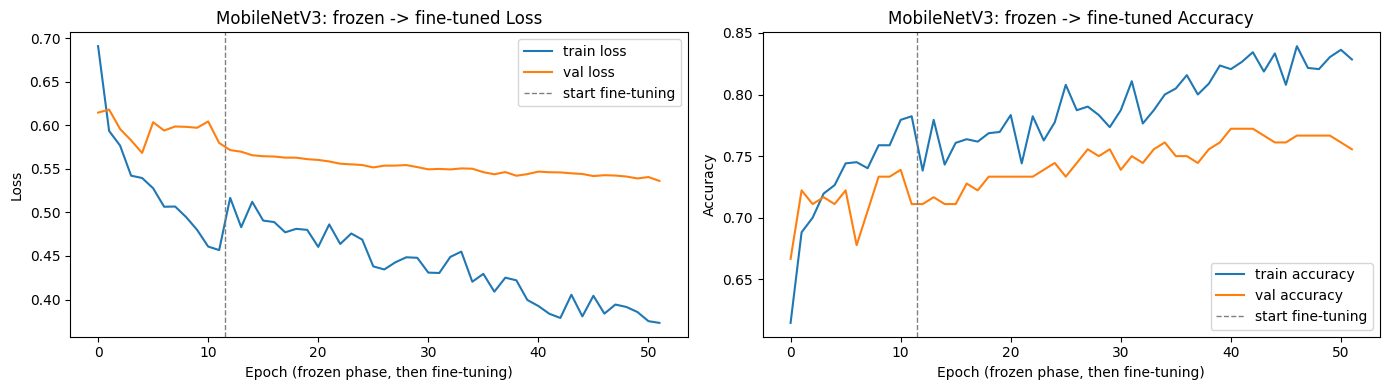


Model                     Best val acc  Test loss  Test acc
MobileNet (frozen)              0.7389     0.5527    0.7233
MobileNet (fine-tuned)          0.7722     0.4930    0.7700
Better test generalization: fine-tuned (+0.0467 test acc)


In [9]:
# ============================================================
# Part 6 - Transfer Learning (MobileNetV3Small) + Fine-tuning
# ============================================================

tf.random.set_seed(42)

# Start from the best *frozen* checkpoint as a separate copy, so `best_mob_frozen`
# stays untouched for the frozen-vs-fine-tuned comparison.
mobilenet_finetuned = load_model(checkpoint_mob_frozen_path)

# The backbone is the nested model with the most layers (the augmentation block only has 4)
base_model_ft = max((l for l in mobilenet_finetuned.layers if hasattr(l, "layers")),
                    key=lambda l: len(l.layers))

# ---- 1) Selective unfreezing: only the last inverted-residual blocks + final conv ----
# Early layers hold generic edge/colour/texture detectors and stay frozen; late blocks hold
# ImageNet-specific semantics, so they are the ones worth adapting to real-vs-AI faces.
FINE_TUNE_FROM_BLOCK = "expanded_conv_9"   # MobileNetV3Small has blocks expanded_conv .. expanded_conv_10
fine_tune_at = next((i for i, l in enumerate(base_model_ft.layers) if l.name.startswith(FINE_TUNE_FROM_BLOCK)),
                    int(len(base_model_ft.layers) * 0.8))   # fallback: top 20% of layers

base_model_ft.trainable = True
for i, layer in enumerate(base_model_ft.layers):
    # BatchNorm layers stay frozen so their ImageNet running statistics are not overwritten
    # by noisy small-batch statistics from our 1,020 training images.
    layer.trainable = (i >= fine_tune_at) and not isinstance(layer, BatchNormalization)

n_trainable_layers = sum([layer.trainable for layer in base_model_ft.layers])
n_trainable_params = int(sum(np.prod(w.shape) for w in mobilenet_finetuned.trainable_weights))
n_total_params = mobilenet_finetuned.count_params()
print(f"Unfreezing from layer {fine_tune_at} ('{base_model_ft.layers[fine_tune_at].name}') "
      f"of {len(base_model_ft.layers)} backbone layers")
print(f"Trainable backbone layers: {n_trainable_layers} / {len(base_model_ft.layers)}")
print(f"Trainable params: {n_trainable_params:,} / {n_total_params:,} "
      f"({100 * n_trainable_params / n_total_params:.1f}%)")

# ---- 2) Recompile with a very small learning rate (delicate updates to pre-trained weights) ----
mobilenet_finetuned.compile(optimizer=Adam(1e-5), loss="binary_crossentropy", metrics=["accuracy"])

checkpoint_mob_ft_path = "best_mobilenet_finetuned.keras"
checkpoint_mob_ft = ModelCheckpoint(checkpoint_mob_ft_path, monitor="val_loss", save_best_only=True, mode="min", verbose=1)
early_stop_mob_ft = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

# Augmentation + dropout in the head + early stopping guard against overfitting
history_mob_finetuned = mobilenet_finetuned.fit(
    X_train_pp, y_train,
    validation_data=(X_val_pp, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[checkpoint_mob_ft, early_stop_mob_ft],
    verbose=1
)

best_val_acc_mob_ft = np.max(history_mob_finetuned.history["val_accuracy"])
best_epoch_mob_ft = np.argmin(history_mob_finetuned.history["val_loss"]) + 1
print(f">> MobileNet (fine-tuned) best val acc: {best_val_acc_mob_ft:.4f} (best val_loss at epoch {best_epoch_mob_ft})")

# ---- 3) Evaluate & compare ----
best_mob_finetuned = load_model(checkpoint_mob_ft_path)
mob_ft_test_loss, mob_ft_test_acc = best_mob_finetuned.evaluate(X_test_pp, y_test, verbose=0)
print(f">> MobileNet (fine-tuned) test acc (best model): {mob_ft_test_acc:.4f}")

# Learning curves: frozen phase followed by fine-tuning phase
n_frozen = len(history_mob_frozen.history["loss"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in ((ax1, "loss", "Loss"), (ax2, "accuracy", "Accuracy")):
    ax.plot(history_mob_frozen.history[metric] + history_mob_finetuned.history[metric], label=f"train {metric}")
    ax.plot(history_mob_frozen.history[f"val_{metric}"] + history_mob_finetuned.history[f"val_{metric}"], label=f"val {metric}")
    ax.axvline(n_frozen - 0.5, color="gray", ls="--", lw=1, label="start fine-tuning")
    ax.set_xlabel("Epoch (frozen phase, then fine-tuning)"); ax.set_ylabel(title)
    ax.set_title(f"MobileNetV3: frozen -> fine-tuned {title}"); ax.legend()
plt.tight_layout(); plt.show()

print(f"\n{'Model':<24}{'Best val acc':>14}{'Test loss':>11}{'Test acc':>10}")
print(f"{'MobileNet (frozen)':<24}{best_val_acc_mob_frozen:>14.4f}{mob_frozen_test_loss:>11.4f}{mob_frozen_test_acc:>10.4f}")
print(f"{'MobileNet (fine-tuned)':<24}{best_val_acc_mob_ft:>14.4f}{mob_ft_test_loss:>11.4f}{mob_ft_test_acc:>10.4f}")
winner = "fine-tuned" if mob_ft_test_acc > mob_frozen_test_acc else ("frozen" if mob_ft_test_acc < mob_frozen_test_acc else "neither (tie)")
print(f"Better test generalization: {winner} ({mob_ft_test_acc - mob_frozen_test_acc:+.4f} test acc)")

### 🤔 Part 6: Think About

**What optimization adjustments protect pre-trained weights from divergence?**
A learning rate about 100× smaller than the one used for the head (1e-5 vs. 1e-3) keeps each update small. The pre-trained filters then shift gradually instead of being overwritten by the large, noisy gradients of a small dataset. Fine-tuning also starts from a head that has already been trained, so the first gradients that reach the backbone are meaningful rather than random. Early stopping on `val_loss`, dropout and augmentation further limit how far the weights can drift.

**Why are late-stage convolutional blocks preferred over early blocks for domain adaptation?**
Early layers learn generic, transferable features such as edges, colour blobs and simple textures, which are useful for almost any image. Late blocks encode ImageNet-specific, high-level concepts (object parts and classes) that matter least for spotting generation artefacts. Adapting only the late blocks re-purposes the most task-specific representations with relatively few parameters, which lowers the risk of overfitting and of catastrophic forgetting.

**Under what conditions does fine-tuning underperform a completely frozen baseline?**
- The dataset is very small relative to the number of unfrozen parameters, so the extra capacity memorises the training set.
- The learning rate is too high, which destroys useful pre-trained features.
- BatchNorm layers are left in training mode, so their running statistics are corrupted by small, unrepresentative batches.
- Too many (early) layers are unfrozen.
- The validation set is small and noisy (here only 180 images), so a slightly better validation score may not carry over to the test set.

**Frozen vs. fine-tuned result:** *(fill in from the printed comparison above, i.e. which one generalised better on the test set and by how much)*

## 🚀 [TO DO] Part 7: Model Comparison & Analysis

### 🏆 **The Ultimate Showdown: Which Model Reigns Supreme?**

Time to put all your models head-to-head! Let's comprehensively compare the performance of all approaches: MLP, CNN baseline, CNN with augmentation, MobileNetV3 transfer learning, and MobileNetV3 fine-tuned.

#### 🎯 **Your Task:**
Create comprehensive visualizations and analyses to compare all models and understand their predictions.

#### 📝 **Required Implementations:**

1. **📈 Performance Comparison Bar Chart**:
   - Create a grouped bar chart showing:
     - Best validation accuracy for each model
     - Test accuracy for each model
   - Models to compare: `MLP`, `CNN`, `CNN+Aug`, `MobileNet`, `MobileNet-FT`
   - Use different colors for validation vs. test metrics

2. **🎭 Confusion Matrices Grid**:
   - Generate predictions for all models on the test set
   - Create a 2×3 subplot grid showing confusion matrices
   - Include model names and test accuracy in titles
   - Use heatmap visualization with annotations showing counts

3. **🖼️ Qualitative Analysis - Sample Predictions**:
   - Select 8-10 interesting test images (mix of correct and incorrect predictions)
   - For each image, display:
     - The actual image
     - True label (T:0 for AI, T:1 for Real)
     - Predictions from ALL models (scores from sigmoid output)
   - Format: Image with model predictions listed below
   - Highlight disagreements between models


#### 💡 **Visualization Tips:**
- Use `plt.subplots()` for organized multi-panel figures
- Color-code: Green for correct predictions, Red for incorrect
- Sort confusion matrix with true labels on y-axis, predicted on x-axis
- For sample images, show probability scores (0.0 = AI, 1.0 = Real)

#### 🔍 **Example Analysis Questions to Answer:**
1. **Performance Ranking**: Which model performs best on the test set?
2. **Generalization**: Which model has the smallest train-validation gap?
3. **Confusion Patterns**: Do certain models favor precision vs. recall?
4. **Failure Cases**: What types of faces fool all models?
5. **Model Consensus**: When models disagree, which one is usually right?

#### 📊 **Expected Outputs:**
```python
Example format for displaying predictions
Image: [displayed]
True: 1 (Real)
MLP: 0.58 ✓ | CNN: 0.45 ✗ | CNN+Aug: 0.50 ✗
MobileNet: 0.75 ✓ | MobileNet-FT: 0.74 ✓

,Best val acc,Test acc,Precision (Real),Recall (Real),Recall (AI),F1 (Real),Train-val gap
MLP,0.706,0.650,0.683,0.560,0.740,0.615,0.096
CNN,0.544,0.493,0.483,0.187,0.800,0.269,-0.011
CNN+Aug,0.639,0.650,0.600,0.900,0.400,0.720,0.117
MobileNet,0.739,0.723,0.719,0.733,0.713,0.726,0.015
MobileNet-FT,0.772,0.770,0.779,0.753,0.787,0.766,0.073


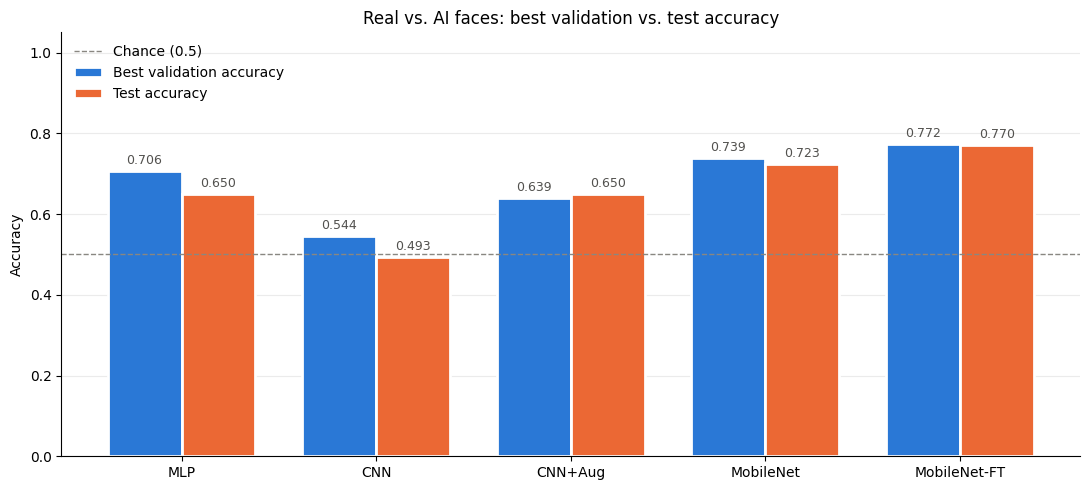

In [10]:
# ============================================================
# Part 7 - Model Comparison: predictions + performance bar chart
# ============================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = ["MLP", "CNN", "CNN+Aug", "MobileNet", "MobileNet-FT"]

# (model, test inputs): MobileNet models take [0, 255] inputs, the others [0, 1]
eval_models = {
    "MLP":          (mlp_model,          X_test),
    "CNN":          (best_cnn,           X_test),
    "CNN+Aug":      (best_cnn_aug,       X_test),
    "MobileNet":    (best_mob_frozen,    X_test_pp),
    "MobileNet-FT": (best_mob_finetuned, X_test_pp),
}
histories = {
    "MLP": history_mlp, "CNN": history_cnn, "CNN+Aug": history_cnn_aug,
    "MobileNet": history_mob_frozen, "MobileNet-FT": history_mob_finetuned,
}
best_val_accs = {
    "MLP": best_val_acc_mlp, "CNN": best_val_acc_cnn, "CNN+Aug": best_val_acc_cnn_aug,
    "MobileNet": best_val_acc_mob_frozen, "MobileNet-FT": best_val_acc_mob_ft,
}
test_accs = {
    "MLP": mlp_test_acc, "CNN": cnn_test_acc, "CNN+Aug": cnn_aug_test_acc,
    "MobileNet": mob_frozen_test_acc, "MobileNet-FT": mob_ft_test_acc,
}

# Sigmoid scores (P(Real)) and hard predictions on the fixed test set
test_probs = {name: m.predict(X, verbose=0).ravel() for name, (m, X) in eval_models.items()}
test_preds = {name: (p >= 0.5).astype(int) for name, p in test_probs.items()}

# ---- Summary table ----
def gap_at_best_epoch(history):
    """Train acc - val acc at the epoch with the lowest val_loss."""
    i = int(np.argmin(history.history["val_loss"]))
    return history.history["accuracy"][i] - history.history["val_accuracy"][i]

summary_df = pd.DataFrame({
    "Best val acc":      [best_val_accs[n] for n in model_names],
    "Test acc":          [test_accs[n] for n in model_names],
    "Precision (Real)":  [precision_score(y_test, test_preds[n], zero_division=0) for n in model_names],
    "Recall (Real)":     [recall_score(y_test, test_preds[n], zero_division=0) for n in model_names],
    "Recall (AI)":       [recall_score(y_test, test_preds[n], pos_label=0, zero_division=0) for n in model_names],
    "F1 (Real)":         [f1_score(y_test, test_preds[n], zero_division=0) for n in model_names],
    "Train-val gap":     [gap_at_best_epoch(histories[n]) for n in model_names],
}, index=model_names)
display(summary_df.style.format("{:.3f}").highlight_max(subset=["Best val acc", "Test acc"], color="#cde2fb"))

# ---- Grouped bar chart: best validation vs. test accuracy ----
VAL_COLOR, TEST_COLOR = "#2a78d6", "#eb6834"
x = np.arange(len(model_names))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
bars_val = ax.bar(x - w/2, summary_df["Best val acc"], w, label="Best validation accuracy", color=VAL_COLOR, edgecolor="white", linewidth=2)
bars_test = ax.bar(x + w/2, summary_df["Test acc"], w, label="Test accuracy", color=TEST_COLOR, edgecolor="white", linewidth=2)
ax.bar_label(bars_val, fmt="%.3f", padding=3, fontsize=9, color="#52514e")
ax.bar_label(bars_test, fmt="%.3f", padding=3, fontsize=9, color="#52514e")
ax.axhline(0.5, color="#898781", ls="--", lw=1, label="Chance (0.5)")
ax.set_xticks(x, model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Real vs. AI faces: best validation vs. test accuracy")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

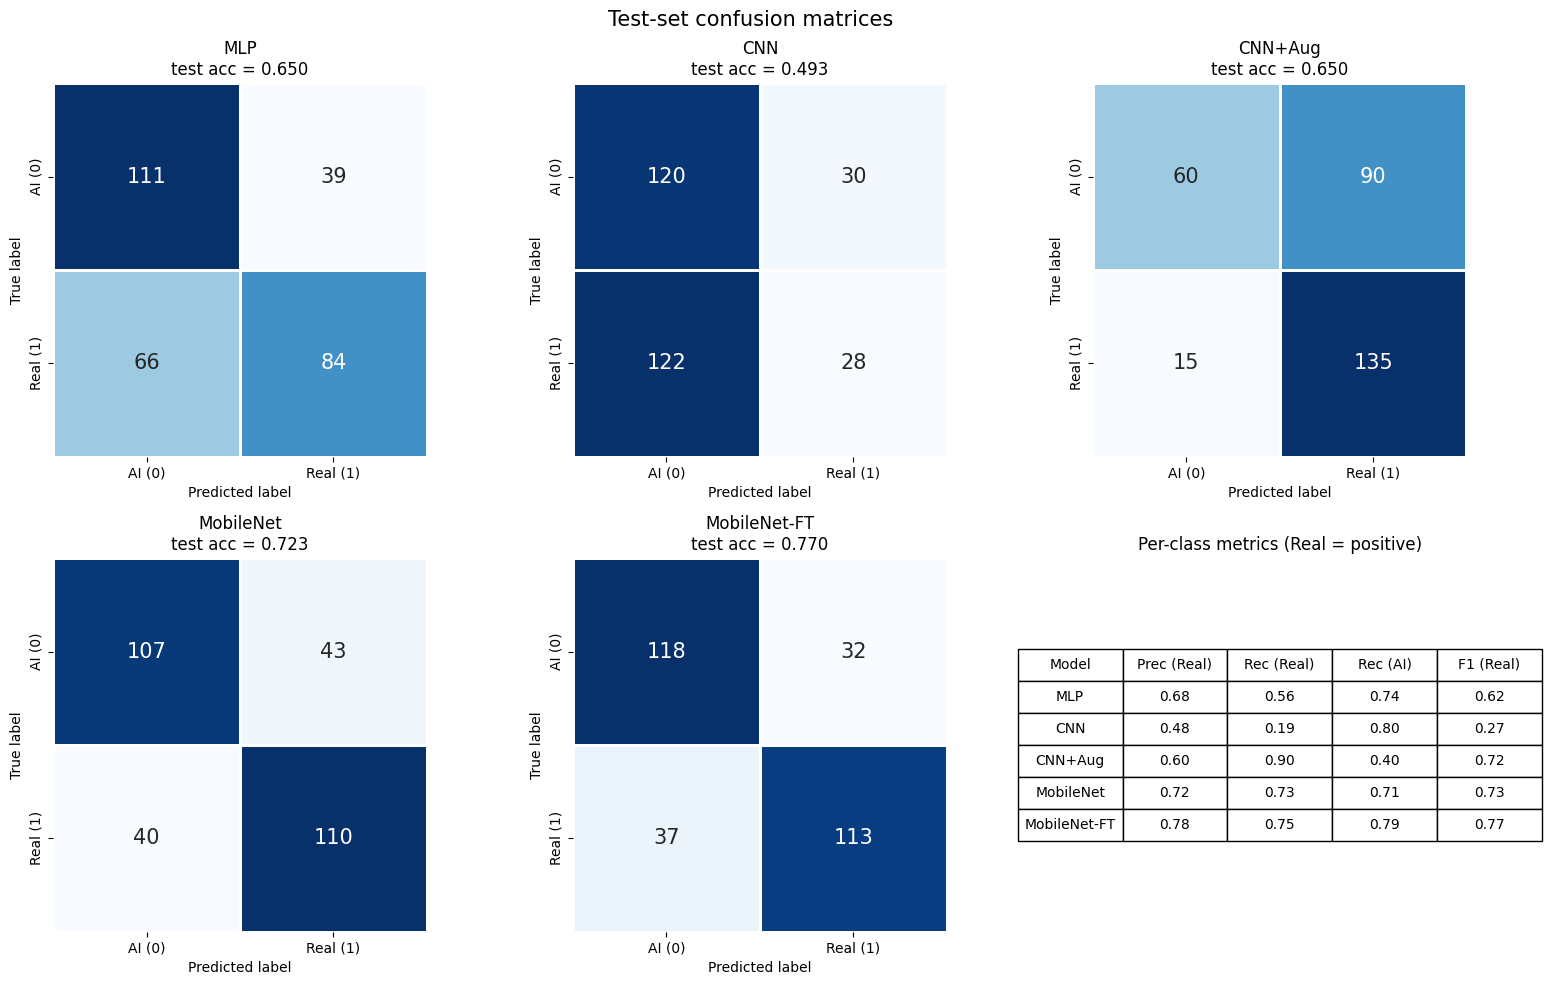

In [11]:
# ============================================================
# Part 7 - Confusion matrices (2x3 grid)
# ============================================================

class_names = ["AI (0)", "Real (1)"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, name in zip(axes.flat, model_names):
    cm = confusion_matrix(y_test, test_preds[name], labels=[0, 1])   # rows = true, cols = predicted
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True, ax=ax,
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 15},
                linewidths=2, linecolor="white")
    ax.set_title(f"{name}\ntest acc = {test_accs[name]:.3f}", fontsize=12)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")

# 6th panel: per-class metrics summary
ax = axes.flat[5]
ax.axis("off")
table = ax.table(
    cellText=[[n,
               f"{summary_df.loc[n, 'Precision (Real)']:.2f}",
               f"{summary_df.loc[n, 'Recall (Real)']:.2f}",
               f"{summary_df.loc[n, 'Recall (AI)']:.2f}",
               f"{summary_df.loc[n, 'F1 (Real)']:.2f}"] for n in model_names],
    colLabels=["Model", "Prec (Real)", "Rec (Real)", "Rec (AI)", "F1 (Real)"],
    loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.1, 1.8)
ax.set_title("Per-class metrics (Real = positive)", fontsize=12)

plt.suptitle("Test-set confusion matrices", fontsize=15)
plt.tight_layout(); plt.show()

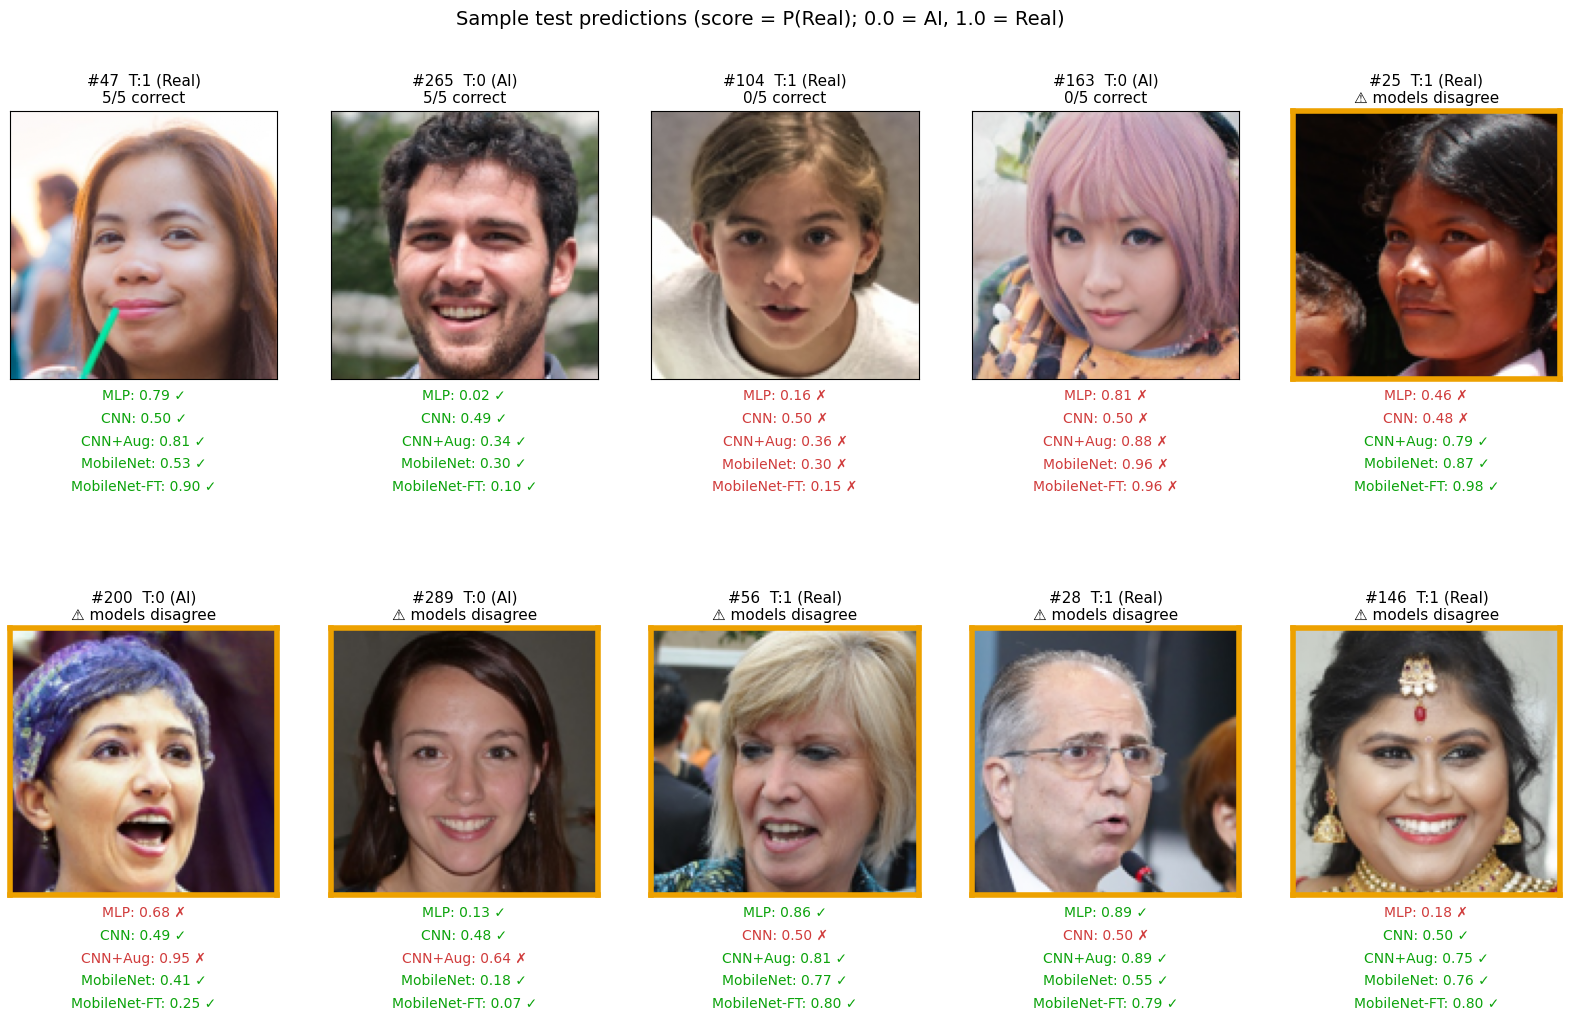

Image #47
True: 1 (Real)
MLP: 0.79 ✓ | CNN: 0.50 ✓ | CNN+Aug: 0.81 ✓
MobileNet: 0.53 ✓ | MobileNet-FT: 0.90 ✓

Image #265
True: 0 (AI)
MLP: 0.02 ✓ | CNN: 0.49 ✓ | CNN+Aug: 0.34 ✓
MobileNet: 0.30 ✓ | MobileNet-FT: 0.10 ✓

Image #104
True: 1 (Real)
MLP: 0.16 ✗ | CNN: 0.50 ✗ | CNN+Aug: 0.36 ✗
MobileNet: 0.30 ✗ | MobileNet-FT: 0.15 ✗

Image #163
True: 0 (AI)
MLP: 0.81 ✗ | CNN: 0.50 ✗ | CNN+Aug: 0.88 ✗
MobileNet: 0.96 ✗ | MobileNet-FT: 0.96 ✗

Image #25  ⚠ models disagree
True: 1 (Real)
MLP: 0.46 ✗ | CNN: 0.48 ✗ | CNN+Aug: 0.79 ✓
MobileNet: 0.87 ✓ | MobileNet-FT: 0.98 ✓

Image #200  ⚠ models disagree
True: 0 (AI)
MLP: 0.68 ✗ | CNN: 0.49 ✓ | CNN+Aug: 0.95 ✗
MobileNet: 0.41 ✓ | MobileNet-FT: 0.25 ✓

Image #289  ⚠ models disagree
True: 0 (AI)
MLP: 0.13 ✓ | CNN: 0.48 ✓ | CNN+Aug: 0.64 ✗
MobileNet: 0.18 ✓ | MobileNet-FT: 0.07 ✓

Image #56  ⚠ models disagree
True: 1 (Real)
MLP: 0.86 ✓ | CNN: 0.50 ✗ | CNN+Aug: 0.81 ✓
MobileNet: 0.77 ✓ | MobileNet-FT: 0.80 ✓

Image #28  ⚠ models disagree
True: 1 (R

In [12]:
# ============================================================
# Part 7 - Qualitative analysis: sample predictions from all models
# ============================================================

GOOD_COLOR, BAD_COLOR = "#0ca30c", "#d03b3b"

P = np.stack([test_probs[n] for n in model_names], axis=1)   # (n_test, n_models) sigmoid scores, P(Real)
n_models = len(model_names)
correct_mat = (P >= 0.5).astype(int) == y_test[:, None]
n_correct = correct_mat.sum(axis=1)

all_right = np.where(n_correct == n_models)[0]
all_wrong = np.where(n_correct == 0)[0]
disagree  = np.where((n_correct > 0) & (n_correct < n_models))[0]

# Pick a mix: 2 that every model gets right, 2 that fool every model, the rest where models disagree
rng = np.random.default_rng(42)
N_SAMPLES = 10
def take(pool, k, exclude):
    pool = np.setdiff1d(pool, exclude)
    return [int(i) for i in rng.choice(pool, size=min(k, len(pool)), replace=False)]

sel = take(all_right, 2, [])
sel += take(all_wrong, 2, sel)
sel += take(disagree, N_SAMPLES - len(sel), sel)
sel += take(np.arange(len(y_test)), N_SAMPLES - len(sel), sel)   # top up if a group was too small

fig, axes = plt.subplots(2, 5, figsize=(20, 10.5))
for ax, i in zip(axes.flat, sel):
    ax.imshow(X_test[i]); ax.set_xticks([]); ax.set_yticks([])
    is_disagree = 0 < n_correct[i] < n_models
    title = f"#{i}  T:{y_test[i]} ({'Real' if y_test[i] == 1 else 'AI'})"
    ax.set_title(title + ("\n⚠ models disagree" if is_disagree else f"\n{n_correct[i]}/{n_models} correct"), fontsize=11)
    if is_disagree:
        for spine in ax.spines.values():
            spine.set_edgecolor("#eda100"); spine.set_linewidth(4)
    for k, name in enumerate(model_names):
        ok = correct_mat[i, k]
        ax.text(0.5, -0.04 - 0.085 * k, f"{name}: {P[i, k]:.2f} {'✓' if ok else '✗'}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10,
                color=GOOD_COLOR if ok else BAD_COLOR)
plt.suptitle("Sample test predictions (score = P(Real); 0.0 = AI, 1.0 = Real)", fontsize=14)
plt.subplots_adjust(hspace=0.6, top=0.91)
plt.show()

# Text version
for i in sel:
    print(f"Image #{i}" + ("  ⚠ models disagree" if 0 < n_correct[i] < n_models else ""))
    print(f"True: {y_test[i]} ({'Real' if y_test[i] == 1 else 'AI'})")
    parts = [f"{name}: {P[i, k]:.2f} {'✓' if correct_mat[i, k] else '✗'}" for k, name in enumerate(model_names)]
    print(" | ".join(parts[:3]))
    print(" | ".join(parts[3:]))
    print()

1) Performance ranking (test accuracy):
   1. MobileNet-FT  0.7700
   2. MobileNet     0.7233
   3. MLP           0.6500
   4. CNN+Aug       0.6500
   5. CNN           0.4933

2) Train-val accuracy gap at the best (lowest val_loss) epoch - smaller = better generalization:
   CNN           -0.0108
   MobileNet     +0.0154
   MobileNet-FT  +0.0729
   MLP           +0.0964
   CNN+Aug       +0.1167
   (CNN+Aug / MobileNet train accuracy is measured on augmented batches with dropout active)

3) Confusion patterns (Real = positive class):
   MLP           precision(Real)=0.683  recall(Real)=0.560  recall(AI)=0.740  predicts Real 41% of the time -> favours 'AI'
   CNN           precision(Real)=0.483  recall(Real)=0.187  recall(AI)=0.800  predicts Real 19% of the time -> favours 'AI'
   CNN+Aug       precision(Real)=0.600  recall(Real)=0.900  recall(AI)=0.400  predicts Real 75% of the time -> favours 'Real'
   MobileNet     precision(Real)=0.719  recall(Real)=0.733  recall(AI)=0.713  predicts 

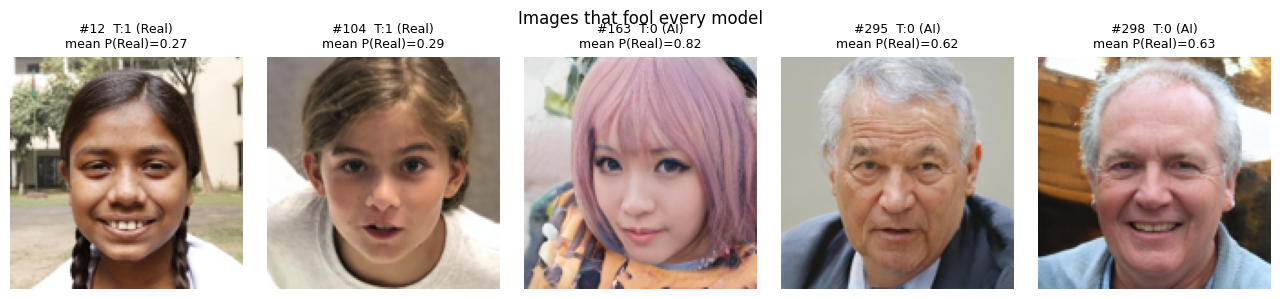


5) Model consensus: models disagree on 258 / 300 test images
   MobileNet-FT  right on 75.2% of disagreement cases
   MobileNet     right on 69.8% of disagreement cases
   MLP           right on 61.2% of disagreement cases
   CNN+Aug       right on 61.2% of disagreement cases
   CNN           right on 43.0% of disagreement cases
   Majority-vote ensemble test accuracy: 0.7533


In [13]:
# ============================================================
# Part 7 - Analysis: numbers for the 5 analysis questions
# ============================================================

print("1) Performance ranking (test accuracy):")
for rank, n in enumerate(sorted(model_names, key=lambda n: test_accs[n], reverse=True), 1):
    print(f"   {rank}. {n:<13} {test_accs[n]:.4f}")

print("\n2) Train-val accuracy gap at the best (lowest val_loss) epoch - smaller = better generalization:")
for n in sorted(model_names, key=lambda n: abs(summary_df.loc[n, "Train-val gap"])):
    print(f"   {n:<13} {summary_df.loc[n, 'Train-val gap']:+.4f}")
print("   (CNN+Aug / MobileNet train accuracy is measured on augmented batches with dropout active)")

print("\n3) Confusion patterns (Real = positive class):")
for n in model_names:
    rec_real, rec_ai = summary_df.loc[n, "Recall (Real)"], summary_df.loc[n, "Recall (AI)"]
    frac_real = test_preds[n].mean()
    bias = "favours 'Real'" if rec_real > rec_ai else ("favours 'AI'" if rec_ai > rec_real else "balanced")
    print(f"   {n:<13} precision(Real)={summary_df.loc[n, 'Precision (Real)']:.3f}  recall(Real)={rec_real:.3f}  "
          f"recall(AI)={rec_ai:.3f}  predicts Real {frac_real:.0%} of the time -> {bias}")

print(f"\n4) Failure cases: {len(all_wrong)} / {len(y_test)} test images fool ALL {n_models} models "
      f"({np.sum(y_test[all_wrong] == 1)} real, {np.sum(y_test[all_wrong] == 0)} AI)")
if len(all_wrong):
    show = all_wrong[:8]
    fig, axes = plt.subplots(1, len(show), figsize=(2.6 * len(show), 3), squeeze=False)
    for ax, i in zip(axes[0], show):
        ax.imshow(X_test[i]); ax.axis("off")
        ax.set_title(f"#{i}  T:{y_test[i]} ({'Real' if y_test[i] == 1 else 'AI'})\nmean P(Real)={P[i].mean():.2f}", fontsize=9)
    plt.suptitle("Images that fool every model"); plt.tight_layout(); plt.show()

print(f"\n5) Model consensus: models disagree on {len(disagree)} / {len(y_test)} test images")
if len(disagree):
    for n, j in sorted(zip(model_names, range(n_models)), key=lambda t: -correct_mat[disagree, t[1]].mean()):
        print(f"   {n:<13} right on {correct_mat[disagree, j].mean():.1%} of disagreement cases")
majority_vote = ((P >= 0.5).sum(axis=1) > n_models / 2).astype(int)
print(f"   Majority-vote ensemble test accuracy: {np.mean(majority_vote == y_test):.4f}")

### 🔍 Part 7: Analysis

*(Answer using the numbers printed by the analysis cell above.)*

1. **Performance ranking:** Which model performs best on the test set?
   - _..._
2. **Generalization:** Which model has the smallest train-validation gap?
   - _..._
3. **Confusion patterns:** Do certain models favor precision vs. recall (i.e. over-predict "Real" or "AI")?
   - _..._
4. **Failure cases:** What types of faces fool all models (lighting, pose, accessories, image quality, ...)?
   - _..._
5. **Model consensus:** When models disagree, which one is usually right?
   - _..._

## 🎮 [TO DO] Part 8: Interactive Game - Human vs. AI Detector

### 🤖 **Can You Beat Your Model?**

Time to make your project interactive! Build a fun game where humans compete against your best-performing model to identify AI-generated faces. Deploy it on Hugging Face Spaces to share with the world!

#### 🎯 **Your Task:**
Create a Gradio interface that gamifies the real vs. AI face detection challenge, then deploy it on Hugging Face Spaces.
- Check out [Which Face is Real?](https://whichfaceisreal.com/) for inspiration


#### 📝 **Implementation Requirements:**

1. **🎯 Core Game Mechanics**:
   - Display pairs or single images from the test set
   - User guesses: Real or AI-generated?
   - Model makes its prediction
   - Compare results and keep score
   - Track accuracy for both human and model

2. **🖼️ Interface Components**:
   - Image display area
   - "Real" and "AI-Generated" buttons for user input
   - Score display (Human vs. Model)
   - "Next Image" button to continue playing
   - Results/feedback area showing correct answer

3. **🎨 Game Features to Implement**:
   - **Round Counter**: Track number of images tested
   - **Live Scoring**: Human accuracy vs. Model accuracy
   - **Feedback**: Reveal correct answer with visual feedback
   - **Final Summary**: After N rounds, show who won!

4. **🚀 Deployment Steps**:
   - Save your best model as `best_model.h5` or `.keras`
   - Create `app.py` with your Gradio interface
   - Create `requirements.txt` with dependencies
   - Deploy to Hugging Face Spaces
   - Test with friends and family!


### >>> **Some Optional Tips**: <<<<
#### 📋 **Gradio Interface Structure**:
Use `gr.Blocks()` for custom layout with themes like `gr.themes.Soft()`. Structure your interface with:
- Title and instructions at the top
- Game area with image and buttons in the middle
- Scores and results at the bottom

#### 💡 **Pro Tips:**
- Pre-load a batch of test images for smooth gameplay
- Make it mobile-responsive with `gr.Blocks()`


#### 🎨 **Design**:
- Make it your own, but consider:
  - A nice layout
  - Scoring systems
  - Creative visual feedback (confetti for wins, color changes)


#### 📦 **Files for Hugging Face Spaces**:
1. `app.py` - Your Gradio application
2. `best_model.keras` - Your trained model
3. `requirements.txt` - Include: `tensorflow`, `gradio`, `numpy`, `Pillow`
4. `test_images/` - Folder with sample test images
5. `README.md` - Describe your project


🚀 **Time to bring your model to life! Create an engaging game that educates and entertains:**

### 🛠️ Part 8 Implementation: Streamlit instead of Gradio

The game below is built with **Streamlit** rather than Gradio. The required game mechanics are the same:
- image display
- "Real" / "AI-Generated" buttons
- the model's prediction for each image
- a round counter
- live Human vs. Model scores
- feedback revealing the correct answer
- a final summary after N rounds

Cells in this part:
1. **Export:** saves the best model as `best_model.keras` and copies the fixed test images into `test_images/`. It also writes `app.py`, `requirements.txt`, `Dockerfile` and `README.md` into `/content/streamlit_app/`.
2. **Optional test:** runs the app from Colab through a temporary Cloudflare tunnel.
3. **Deploy:**
   - to a Hugging Face Space (Docker SDK running Streamlit), or
   - by downloading the bundle and deploying it on Streamlit Community Cloud.

**App URL:** _(paste your deployed URL here)_

In [14]:
# ============================================================
# Part 8 - Export best model, test images & deployment files
# ============================================================

import json
import shutil
from importlib.metadata import version

APP_DIR = "/content/streamlit_app"
GAME_ROUNDS = 10   # rounds per game in the app
os.makedirs(APP_DIR, exist_ok=True)

# ---- 1) Pick the best-performing model on the fixed test set and save it ----
# input_scale: MobileNet models expect [0, 255] pixels, the others [0, 1]
candidates = {
    "MLP":          (mlp_model,          1.0),
    "CNN":          (best_cnn,           1.0),
    "CNN+Aug":      (best_cnn_aug,       1.0),
    "MobileNet":    (best_mob_frozen,    255.0),
    "MobileNet-FT": (best_mob_finetuned, 255.0),
}
best_name = max(candidates, key=lambda n: test_accs[n])
best_model, input_scale = candidates[best_name]
print(f"🏆 Best model: {best_name} (test acc {test_accs[best_name]:.4f})")

best_model.save("best_model.keras")
best_model.save(os.path.join(APP_DIR, "best_model.keras"))
with open(os.path.join(APP_DIR, "model_config.json"), "w", encoding="utf-8") as f:
    json.dump({"model_name": best_name, "input_scale": input_scale,
               "test_acc": round(float(test_accs[best_name]), 4),
               "n_rounds": GAME_ROUNDS}, f, indent=2)

# ---- 2) Copy the fixed test images (original files) into test_images/{real,ai}/ ----
valid_extensions = ('.jpg', '.jpeg')
for sub, src in (("real", "test_real"), ("ai", "test_AI")):
    dst = os.path.join(APP_DIR, "test_images", sub)
    os.makedirs(dst, exist_ok=True)
    src_dir = os.path.join(data_path, src)
    for fname in sorted(os.listdir(src_dir)):
        if not fname.startswith('.') and fname.lower().endswith(valid_extensions):
            shutil.copy(os.path.join(src_dir, fname), dst)
    print(f"   copied {len(os.listdir(dst))} images -> test_images/{sub}/")

# ---- 3) Sanity check: the app's preprocessing reproduces the notebook's prediction ----
reloaded = load_model(os.path.join(APP_DIR, "best_model.keras"))
first_real = sorted(os.listdir(os.path.join(APP_DIR, "test_images", "real")))[0]
img = Image.open(os.path.join(APP_DIR, "test_images", "real", first_real)).convert("RGB").resize((128, 128))
x_app = (np.asarray(img, dtype=np.float32) / 255.0 * input_scale)[None]
p_app = float(reloaded.predict(x_app, verbose=0)[0, 0])
p_nb = float(best_model.predict((X_test[:1] * input_scale).astype("float32"), verbose=0)[0, 0])
print(f"Sanity check on {first_real}: app P(Real)={p_app:.4f} vs notebook P(Real)={p_nb:.4f}")
assert abs(p_app - p_nb) < 1e-3, "App preprocessing does not match the notebook!"

# ---- 4) requirements.txt (pinned to the versions the model was trained/saved with) ----
with open(os.path.join(APP_DIR, "requirements.txt"), "w", encoding="utf-8") as f:
    f.write(f"tensorflow=={tf.__version__}\n"
            f"keras=={version('keras')}\n"
            f"numpy=={np.__version__}\n"
            f"Pillow=={version('Pillow')}\n"
            "streamlit>=1.36\n")

# ---- 5) Dockerfile (Hugging Face Spaces, Docker SDK) ----
with open(os.path.join(APP_DIR, "Dockerfile"), "w", encoding="utf-8") as f:
    f.write("""FROM python:3.12-slim

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user PATH=/home/user/.local/bin:$PATH
WORKDIR $HOME/app

COPY --chown=user requirements.txt .
RUN pip install --no-cache-dir --upgrade pip && pip install --no-cache-dir -r requirements.txt
COPY --chown=user . .

EXPOSE 8501
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--browser.gatherUsageStats=false"]
""")

# ---- 6) README.md (front-matter configures the HF Space) ----
with open(os.path.join(APP_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write(f"""---
title: Real or AI Face Game
emoji: 🤖
colorFrom: blue
colorTo: red
sdk: docker
app_port: 8501
pinned: false
---

# 🕵️ Real or AI? Human vs. Model

A small game from CS6180 HW1 (Foundations of GenAI). You are shown faces from the course's fixed
test set and have to decide whether each one is a **real photo** or **AI-generated**. A trained
classifier (**{best_name}**, {test_accs[best_name]:.1%} test accuracy) plays the same rounds, and after
{GAME_ROUNDS} rounds the game shows who did better.

- `app.py`: Streamlit app
- `best_model.keras`: trained Keras model
- `model_config.json`: model name and input scaling
- `test_images/real`, `test_images/ai`: test images

Run locally: `pip install -r requirements.txt && streamlit run app.py`
""")

print(f"\n✅ App files written to {APP_DIR}:")
for root, dirs, fnames in os.walk(APP_DIR):
    if "test_images" in root:
        continue
    for fname in sorted(fnames):
        print("  ", os.path.relpath(os.path.join(root, fname), APP_DIR))

🏆 Best model: MobileNet-FT (test acc 0.7700)


   copied 150 images -> test_images/real/


   copied 150 images -> test_images/ai/


Sanity check on 01353.jpg: app P(Real)=0.2017 vs notebook P(Real)=0.2017

✅ App files written to /content/streamlit_app:
   Dockerfile
   README.md
   best_model.keras
   model_config.json
   requirements.txt


In [15]:
%%writefile /content/streamlit_app/app.py
# ============================================================
# Part 8 - Streamlit game: Human vs. AI Detector  (app.py)
# ============================================================
import json
import random
from pathlib import Path

import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

APP_DIR = Path(__file__).parent
IMG_DIR = APP_DIR / "test_images"
LABELS = {1: "Real", 0: "AI-Generated"}

st.set_page_config(page_title="Real or AI?", page_icon="🕵️", layout="centered")


@st.cache_resource
def load_model():
    cfg = json.loads((APP_DIR / "model_config.json").read_text())
    model = tf.keras.models.load_model(APP_DIR / "best_model.keras")
    return model, cfg


@st.cache_data
def load_image_list():
    """(path, label) for every test image; label 1 = Real, 0 = AI (same convention as training)."""
    items = []
    for label, sub in ((1, "real"), (0, "ai")):
        for p in sorted((IMG_DIR / sub).iterdir()):
            if p.suffix.lower() in (".jpg", ".jpeg", ".png"):
                items.append((str(p), label))
    return items


def model_predict(path):
    """P(Real) for one image, preprocessed exactly like the notebook (resize to 128x128, scale)."""
    model, cfg = load_model()
    img = Image.open(path).convert("RGB").resize((128, 128))
    x = np.asarray(img, dtype=np.float32) / 255.0 * cfg["input_scale"]
    return float(model.predict(x[None, ...], verbose=0)[0, 0])


model, cfg = load_model()
images = load_image_list()
N_ROUNDS = min(int(cfg.get("n_rounds", 10)), len(images))


# ---- Game state ----
def new_game():
    ss = st.session_state
    ss.deck = random.sample(range(len(load_image_list())), N_ROUNDS)
    ss.round = 0          # index of the current round
    ss.human = 0          # human score
    ss.model = 0          # model score
    ss.result = None      # feedback for the current round once the human has guessed
    ss.log = []
    ss.celebrated = False


def submit_guess(guess):
    ss = st.session_state
    path, label = load_image_list()[ss.deck[ss.round]]
    prob = model_predict(path)
    model_guess = int(prob >= 0.5)
    ss.human += int(guess == label)
    ss.model += int(model_guess == label)
    ss.result = {"label": label, "guess": guess, "prob": prob, "model_guess": model_guess}
    ss.log.append({
        "Round": ss.round + 1,
        "Answer": LABELS[label],
        "You": ("✅ " if guess == label else "❌ ") + LABELS[guess],
        "Model": ("✅ " if model_guess == label else "❌ ") + f"{LABELS[model_guess]} (P(Real)={prob:.2f})",
    })


def next_round():
    st.session_state.round += 1
    st.session_state.result = None


if "deck" not in st.session_state:
    new_game()
ss = st.session_state

# ---- Header ----
st.title("🕵️ Real or AI? Human vs. Model")
st.write(
    f"Each round shows a face. Decide whether it's a **real photo** or **AI-generated**. "
    f"Our best classifier (**{cfg['model_name']}**, {cfg['test_acc']:.0%} test accuracy) "
    f"plays the same images. After **{N_ROUNDS} rounds**, whoever has more correct answers wins."
)

# ---- Scoreboard ----
rounds_played = len(ss.log)
c1, c2, c3 = st.columns(3)
c1.metric("Round", f"{min(ss.round + 1, N_ROUNDS)} / {N_ROUNDS}")
c2.metric("🧑 You", ss.human, f"{ss.human / rounds_played:.0%} accuracy" if rounds_played else None, delta_color="off")
c3.metric("🤖 Model", ss.model, f"{ss.model / rounds_played:.0%} accuracy" if rounds_played else None, delta_color="off")
st.progress(rounds_played / N_ROUNDS)

# ---- Final summary ----
if ss.round >= N_ROUNDS:
    st.header("🏁 Final results")
    if ss.human > ss.model:
        st.success(f"🎉 You win, {ss.human} to {ss.model}! Humans 1, machines 0.")
        if not ss.celebrated:
            st.balloons()
            ss.celebrated = True
    elif ss.human < ss.model:
        st.error(f"🤖 The model wins, {ss.model} to {ss.human}. Spotting AI faces is hard!")
    else:
        st.info(f"🤝 It's a tie at {ss.human} each!")
    st.dataframe(ss.log, hide_index=True)
    st.button("🔁 Play again", on_click=new_game, type="primary")
    st.stop()

# ---- Current round ----
path, label = images[ss.deck[ss.round]]
st.image(path, width=380)

if ss.result is None:
    b1, b2 = st.columns(2)
    b1.button("📸 Real", on_click=submit_guess, args=(1,), type="primary")
    b2.button("🤖 AI-Generated", on_click=submit_guess, args=(0,), type="primary")
else:
    r = ss.result
    truth = LABELS[r["label"]]
    if r["guess"] == r["label"]:
        st.success(f"✅ Correct! This face is **{truth}**.")
    else:
        st.error(f"❌ Not quite. This face is **{truth}**.")
    model_ok = r["model_guess"] == r["label"]
    confidence = r["prob"] if r["model_guess"] == 1 else 1 - r["prob"]
    model_msg = (f"🤖 The model said **{LABELS[r['model_guess']]}** with {confidence:.0%} confidence "
                 f"(P(Real) = {r['prob']:.2f}), which is {'correct ✅' if model_ok else 'wrong ❌'}.")
    (st.info if model_ok else st.warning)(model_msg)
    last_round = ss.round + 1 >= N_ROUNDS
    st.button("🏁 See final results" if last_round else "➡️ Next image", on_click=next_round, type="primary")

Writing /content/streamlit_app/app.py


In [16]:
# ============================================================
# Part 8 - Test the app from Colab (optional, via a temporary Cloudflare tunnel)
# ============================================================
# Set RUN_LOCAL_TEST = True to launch the app and get a temporary public *.trycloudflare.com link.

RUN_LOCAL_TEST = False

if RUN_LOCAL_TEST:
    import re, subprocess, time
    !pip install -q streamlit
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared && chmod +x /content/cloudflared

    streamlit_proc = subprocess.Popen(
        ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true",
         "--browser.gatherUsageStats", "false"],
        cwd=APP_DIR, stdout=open("/content/streamlit.log", "w"), stderr=subprocess.STDOUT)
    tunnel_proc = subprocess.Popen(
        ["/content/cloudflared", "tunnel", "--url", "http://localhost:8501", "--no-autoupdate"],
        stdout=open("/content/cloudflared.log", "w"), stderr=subprocess.STDOUT)

    public_url = None
    for _ in range(30):
        time.sleep(1)
        match = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com", open("/content/cloudflared.log").read())
        if match:
            public_url = match.group(0)
            break
    print(f"🎮 Play here: {public_url}" if public_url else "Tunnel not ready - check /content/cloudflared.log")
    # To stop: streamlit_proc.terminate(); tunnel_proc.terminate()

In [17]:
# ============================================================
# Part 8 - Deploy (Hugging Face Spaces, Docker + Streamlit) / download bundle
# ============================================================
# Option A (automatic): Hugging Face Space. Needs a HF *write* token stored as the Colab secret
#   "HF_TOKEN" (key icon in the left sidebar). Set DEPLOY_TO_HF = True and your Space id.
# Option B (manual): download the zip and push its contents to a public GitHub repo, then deploy
#   it on Streamlit Community Cloud (share.streamlit.io) with app file = app.py, Python 3.12.

DEPLOY_TO_HF = False
HF_SPACE_ID = "your-hf-username/real-or-ai-face-game"

import shutil
zip_path = shutil.make_archive("/content/streamlit_app", "zip", APP_DIR)
print(f"📦 App bundle: {zip_path}")
try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print(f"(Download it manually from the file browser: {e})")

if DEPLOY_TO_HF:
    from huggingface_hub import HfApi
    from google.colab import userdata
    api = HfApi(token=userdata.get("HF_TOKEN"))
    api.create_repo(repo_id=HF_SPACE_ID, repo_type="space", space_sdk="docker", exist_ok=True)
    api.upload_folder(folder_path=APP_DIR, repo_id=HF_SPACE_ID, repo_type="space",
                      commit_message="Deploy Real-or-AI Streamlit game")
    print(f"🚀 Deployed! The Space builds in a few minutes: https://huggingface.co/spaces/{HF_SPACE_ID}")

📦 App bundle: /content/streamlit_app.zip
(Download it manually from the file browser: No module named 'google.colab')


## 📦 Final Deliverables

Submit the following:

1. **Completed Colab Notebook URL**
   - Fully executed with all outputs visible
   
2. **Brief Report (2-3 pages PDF)**
   - Model performance comparison table
   - Key learning curves
   - Main insights and conclusions
   
3. **Hugging Face Spaces URL**
   - Working Gradio demo with your best model

## ✅ Submission Checklist

Before submitting, ensure you have:
- [ ] Completed all code sections (Parts 4-7)
- [ ] All models train properly (no clear signs of overfitting/underfitting)
- [ ] Created all required visualizations
- [ ] Colab runs without errors from top to bottom
- [ ] Report is informative and concise (≤3 pages)
- [ ] Gradio app successfully deployed and working
- [ ] All URLs are accessible and functional

**Good luck! 🚀**